# EDA: coverage and bias diagnostics

This notebook uses **existing saved outputs** in `eda_workbook.ipynb`. It does not download papers, execute that notebook, or alter its data.

The checkout has no raw metadata catalog or paper-level EDA CSV. Therefore these charts are diagnostics of recorded results, **not a fresh corpus audit or proof of fairness**. Saved cells reflect different execution states; do not combine their counts into a funnel.

Run from the repository root. Python and Matplotlib are required. If Matplotlib is missing, install it in your notebook kernel with `%pip install matplotlib`, then restart the kernel. No output folders are created; charts appear inline.

See [branch summary](../docs/EDA_BRANCH_SUMMARY.md) and [limitations](../docs/EDA_LIMITATIONS.md).

In [6]:
import json
import re
import hashlib
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

root = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebooks" / "eda_workbook.ipynb").is_file()), None)
if root is None:
    raise FileNotFoundError("Open this notebook from the repository root or workbook folder.")
source_path = root / "notebooks" / "eda_workbook.ipynb"
source_bytes = source_path.read_bytes()
original = json.loads(source_bytes)
source_cells = original["cells"]

def source(cell):
    return "".join(cell.get("source", []))

def output_text(cell):
    result = []
    for output in cell.get("outputs", []):
        for value in [output.get("text"), output.get("data", {}).get("text/plain")]:
            if value:
                result.append("".join(value) if isinstance(value, list) else value)
    return "\n".join(result)

def find_cell(fragment):
    matches = [(i, cell) for i, cell in enumerate(source_cells)
               if cell["cell_type"] == "code" and fragment in source(cell)]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one cell containing {fragment!r}; found {len(matches)}.")
    return matches[0]

def saved_match(fragment, pattern):
    i, cell = find_cell(fragment)
    match = re.search(pattern, output_text(cell))
    if not match:
        raise ValueError(f"Saved output missing or changed in source cell {i + 1}: {pattern}")
    return i + 1, int(match.group(1))

plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Source:", source_path.relative_to(root))
print("SHA-256:", hashlib.sha256(source_bytes).hexdigest())
print("Mode: recorded notebook outputs; cells are NOT re-executed.")

Source: notebooks\eda_workbook.ipynb
SHA-256: a8f6b5326249dd05c53403bfb5e44439cd1003f92926265a66728cc7191afd3c
Mode: recorded notebook outputs; cells are NOT re-executed.


## 1. Topic coverage versus the collection design

**Question:** Does observed area coverage follow the intended quotas?

The original design requests 30 general papers and 10 per business area. The saved percentages use **area assignments** as the denominator, not unique papers. A paper may belong to multiple areas. Small gaps can reflect overlap, failed acquisition, exclusions, or mixed execution states; this chart cannot distinguish those explanations.

Equal quotas are a design choice, not a reference distribution proving representativeness.

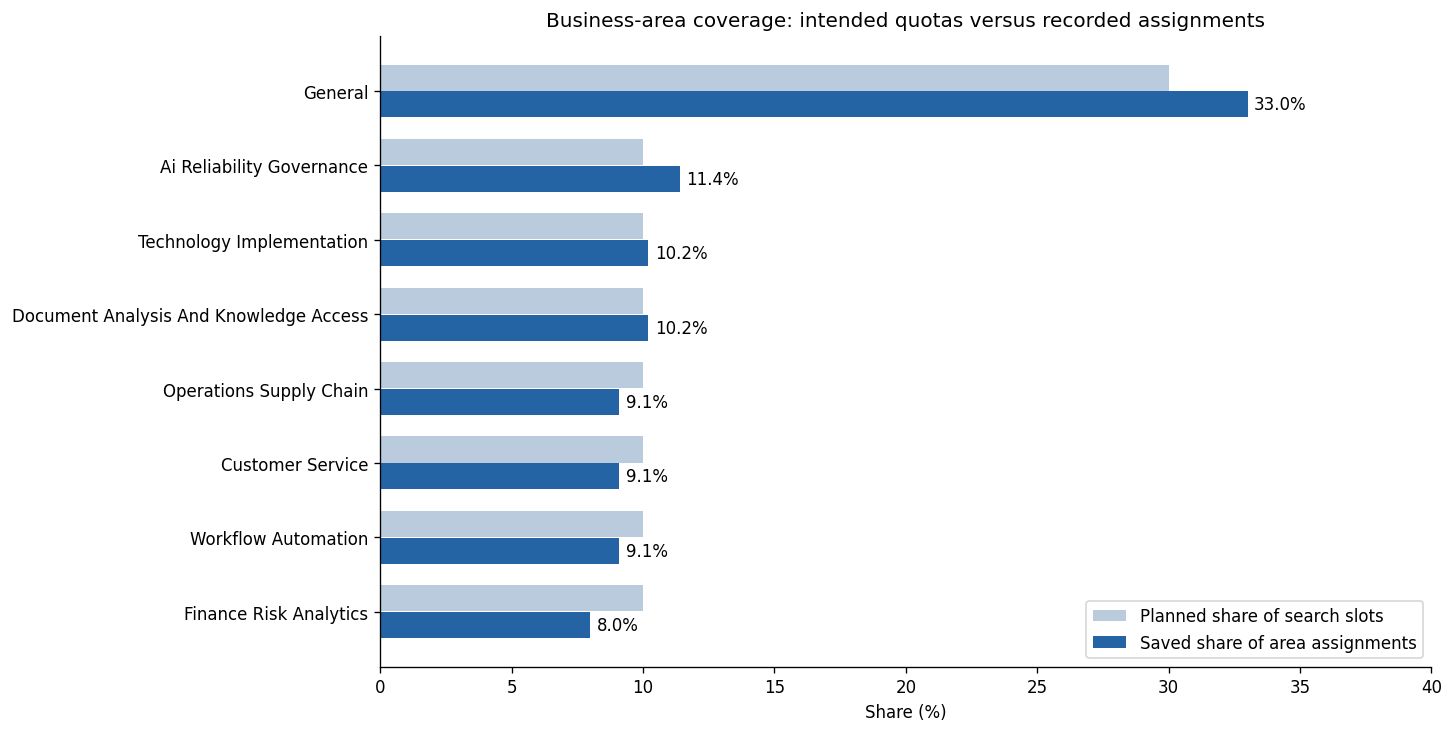

Source cell 35. Rounded percentages sum to 100.1%.
General exceeds its 30% design share; finance is below its 10% share.
Next: reconcile one snapshot, then review relevance before changing quotas.


In [7]:
stats_index, stats_cell = find_cell('print(f"Top 10 arXiv categories')
stats_text = output_text(stats_cell)
area_pairs = re.findall(r"^([a-z][a-z_]+)\s+(\d+(?:\.\d+)?)%\s*$", stats_text, re.M)
if len(area_pairs) != 8:
    raise ValueError("Expected the eight saved collection-area percentages.")
areas = dict((name, float(value)) for name, value in area_pairs)
names = sorted(areas, key=areas.get, reverse=True)
observed = [areas[name] for name in names]
target = [30 if name == "general" else 10 for name in names]
labels = [name.replace("_", " ").title() for name in names]
positions = list(range(len(names)))

fig, ax = plt.subplots(figsize=(12, 6), layout="constrained")
ax.barh([p - .18 for p in positions], target, height=.35,
        color="#bacbdd", label="Planned share of search slots")
bars = ax.barh([p + .18 for p in positions], observed, height=.35,
              color="#2464a5", label="Saved share of area assignments")
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set(yticks=positions, yticklabels=labels, xlabel="Share (%)", xlim=(0, 40),
       title="Business-area coverage: intended quotas versus recorded assignments")
ax.invert_yaxis()
ax.legend(loc="lower right")
plt.show()
print(f"Source cell {stats_index + 1}. Rounded percentages sum to {sum(observed):.1f}%.")
print("General exceeds its 30% design share; finance is below its 10% share.")
print("Next: reconcile one snapshot, then review relevance before changing quotas.")

## 2. Concentration in the reported research categories

**Question:** Are some research fields much more visible than others?

These are the original notebook's **top ten category-label counts**. Categories overlap and the omitted categories are unknown here. Do not turn these counts into shares of the full corpus. The original mapping assigns the same label, 'Machine Learning', to both `cs.LG` and `stat.ML`; a paper with both can be counted twice under that name.

Use this plot to motivate a category-code audit and stakeholder coverage review, not a fairness conclusion.

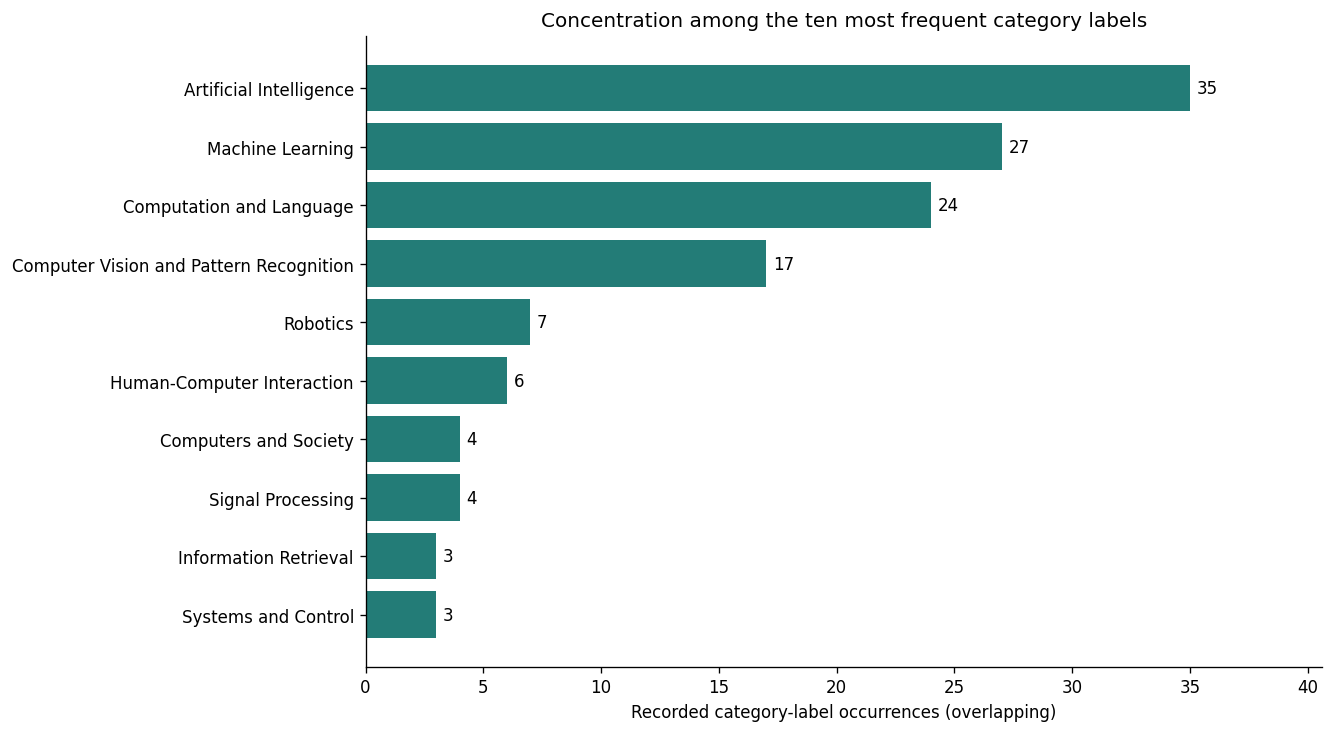

Next: use raw category codes and deduplicate each paper/category pair.
Technical-field concentration can narrow evidence coverage; relevance needs human review.


In [8]:
category_pairs = re.findall(r"^([A-Z][A-Za-z ,&()/-]+?)\s{2,}(\d+)\s*$",
                            stats_text, re.M)
if len(category_pairs) != 10:
    raise ValueError("Expected ten saved category counts; inspect the source output.")
category_pairs = sorted([(name.strip(), int(n)) for name, n in category_pairs],
                        key=lambda item: item[1])
fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
bars = ax.barh([name for name, _ in category_pairs],
              [n for _, n in category_pairs], color="#237c77")
ax.bar_label(bars, padding=4)
ax.set(xlabel="Recorded category-label occurrences (overlapping)",
       title="Concentration among the ten most frequent category labels")
ax.set_xlim(0, max(n for _, n in category_pairs) * 1.16)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()
print("Next: use raw category codes and deduplicate each paper/category pair.")
print("Technical-field concentration can narrow evidence coverage; relevance needs human review.")

## 3. Document length and possible retrieval exposure bias

**Question:** Could long papers supply disproportionately many chunks?

This plot uses the saved `describe()` summary of approximate word counts. It displays the minimum, first quartile, median, third quartile, and maximum—**not raw observations**. Whiskers show the full range rather than the usual 1.5-IQR rule; individual outliers and the detailed distribution cannot be recovered.

Word count is a possible driver of chunk volume, not a measurement of retrieval exposure. Verify with actual chunk counts and benchmark results before applying caps.

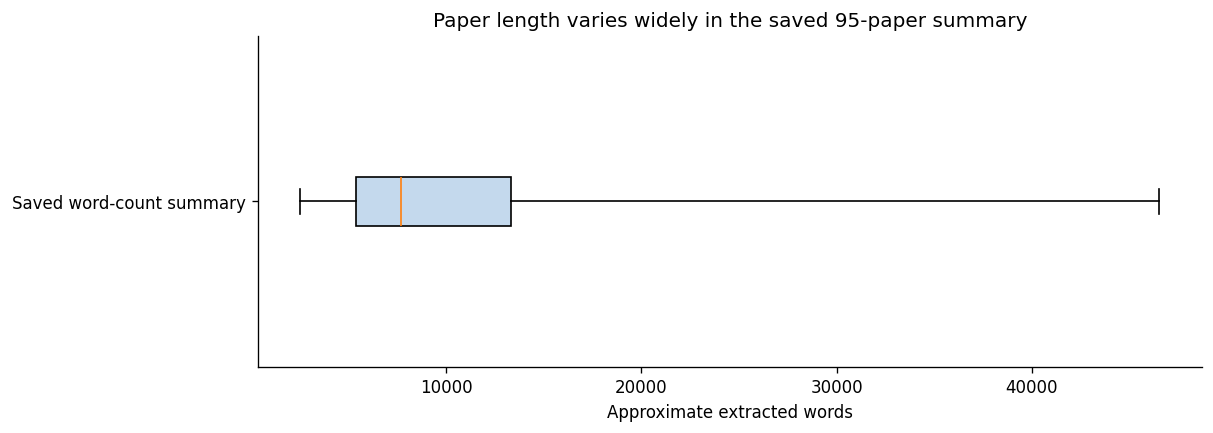

Source cell 33; minimum 2,533, median 7,693, maximum 46,527 words.
Maximum / median = 6.0.
Next: inspect words/chunks per paper and rank exposure on the same corpus.


In [9]:
extraction_index, extraction_cell = find_cell('pages_by_paper = {}')
summary_text = next(("".join(o.get("data", {}).get("text/plain", []))
                     for o in extraction_cell.get("outputs", [])
                     if "count" in "".join(o.get("data", {}).get("text/plain", []))
                     and "mean" in "".join(o.get("data", {}).get("text/plain", []))), None)
if summary_text is None:
    raise ValueError("Saved descriptive statistics are unavailable.")
summary = {}
for line in summary_text.splitlines():
    match = re.match(r"^(count|min|25%|50%|75%|max)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s*$", line)
    if match:
        summary[match[1]] = float(match[4])
if set(summary) != {"count", "min", "25%", "50%", "75%", "max"}:
    raise ValueError("Unexpected descriptive-statistics format.")
box = dict(label="Saved word-count summary", whislo=summary["min"],
           q1=summary["25%"], med=summary["50%"], q3=summary["75%"],
           whishi=summary["max"], fliers=[])
fig, ax = plt.subplots(figsize=(10, 3.5), layout="constrained")
ax.bxp([box], vert=False, showfliers=False, patch_artist=True,
       boxprops={"facecolor": "#c4d9ed"})
ax.set(xlabel="Approximate extracted words",
       title=f"Paper length varies widely in the saved {int(summary['count'])}-paper summary")
plt.show()
print(f"Source cell {extraction_index + 1}; minimum {summary['min']:,.0f}, "
      f"median {summary['50%']:,.0f}, maximum {summary['max']:,.0f} words.")
print(f"Maximum / median = {summary['max'] / summary['50%']:.1f}.")
print("Next: inspect words/chunks per paper and rank exposure on the same corpus.")

## 4. Snapshot inconsistency: a prerequisite for a reliable bias audit

**Question:** Can the notebook's saved findings describe a single corpus?

The bars below are **separate recorded observations**, not sequential losses from one cohort. The 85-paper narrative and 97-paper catalog output coexist with a 95-paper extraction summary. No dropout rate can be inferred without matching paper IDs and run timestamps. The partial 16-PDF download result is also a different execution state.

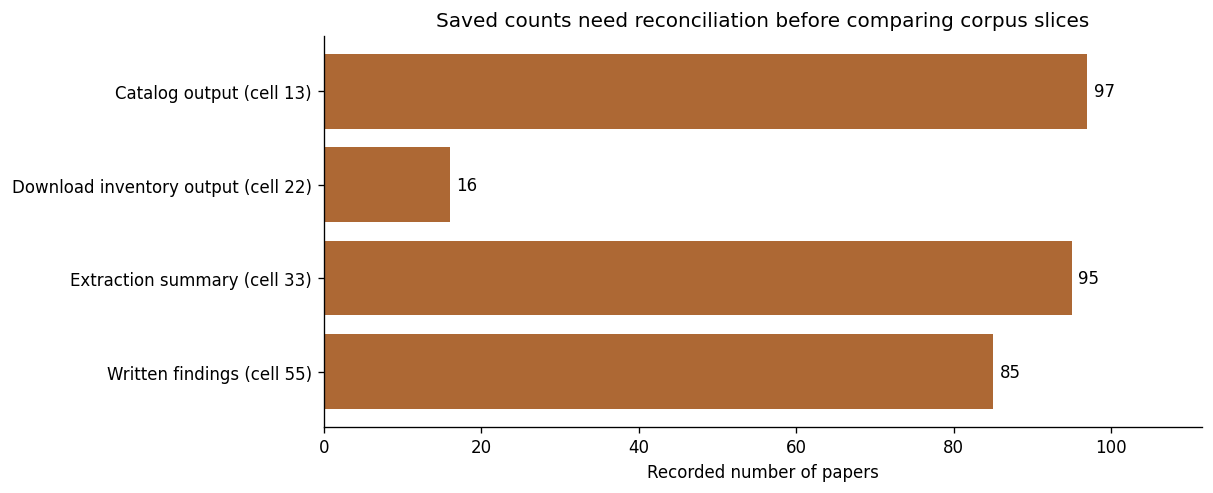

These are not a funnel. Resolve differences using one fixed catalog and matching PDF IDs.


In [10]:
catalog_cell, catalog_n = saved_match('print("Unique papers:"', r"Unique papers:\s*(\d+)")
download_cell, download_n = saved_match('print(f"\\nPDF count:', r"PDF count:\s*(\d+)")
narratives = [(i, source(c)) for i, c in enumerate(source_cells)
              if c["cell_type"] == "markdown" and "## EDA Findings" in source(c)]
if len(narratives) != 1:
    raise ValueError("Expected one original findings section.")
narrative_index, narrative = narratives[0]
m = re.search(r"\*\*(\d+) research papers\*\*", narrative)
if not m:
    raise ValueError("The saved narrative paper count is unavailable.")
observations = [
    ("Catalog output", catalog_n, catalog_cell),
    ("Download inventory output", download_n, download_cell),
    ("Extraction summary", int(summary["count"]), extraction_index + 1),
    ("Written findings", int(m.group(1)), narrative_index + 1),
]
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
bars = ax.barh([f"{label} (cell {cell})" for label, n, cell in observations],
              [n for label, n, cell in observations], color="#ad6834")
ax.bar_label(bars, padding=4)
ax.set(xlabel="Recorded number of papers", xlim=(0, max(n for _, n, _ in observations) * 1.15),
       title="Saved counts need reconciliation before comparing corpus slices")
ax.invert_yaxis()
plt.show()
print("These are not a funnel. Resolve differences using one fixed catalog and matching PDF IDs.")

## What these figures justify—and what remains unmeasured

- **Selection/coverage risk:** area shares and category counts justify reviewing search terms, topic coverage, and relevance. They do not establish a representative research sample.
- **Length-related exposure risk:** observed word-count variation justifies measuring chunks and retrieval frequency per paper. More words do not automatically mean unfair retrieval.
- **Reproducibility gap:** reconcile saved counts before reporting exclusion rates, missingness rates, or comparisons between groups.
- **Still unmeasured:** human relevance rates, publication-date distribution, metadata missingness, language/geographic coverage, and retrieval quality by business area. Raw records or completed review labels are required; they must not be invented from partial displayed rows.
- **Next preprocessing checks:** inspect extraction warnings and page fidelity; preserve IDs/versions/page spans; validate section parsing; test boilerplate/reference filtering.

A lack of protected-group labels means this is a corpus-coverage audit, not a demographic fairness assessment. See [EDA limitations](../docs/EDA_LIMITATIONS.md) for details.